### Analista d'experiència del client


Hi ha una relació entre el preu de l'allotjament i la satisfacció general dels clients? Com varia aquesta relació en funció de les diferents ciutats on s'ubiquen els allotjaments?

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

In [32]:
df = pd.read_csv("../../Data/clean_data_24-03-2026.csv", parse_dates=['insert_date','first_review_date','last_review_date'])

pd.set_option('display.max_columns', 40)

# Selecciono solo las columnas que nos interesan para visualizar más fácil

df[['apartment_id',
    'room_type', 
    'price',
    'number_of_reviews',
    'review_scores_rating',
    'review_scores_accuracy',
    'review_scores_cleanliness',
    'review_scores_checkin',
    'review_scores_communication',
    'review_scores_location',
    'review_scores_value',
    'reviews_per_month',
    'city']]

,apartment_id,room_type,price,number_of_reviews,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,reviews_per_month,city
0,11964,Private room,400.0,78,97.0,100.0,100.0,100.0,100.0,100.0,100.0,75.0,Malaga
1,21853,Private room,170.0,33,92.0,90.0,90.0,100.0,100.0,80.0,90.0,52.0,Madrid
2,32347,Entire home/apt,990.0,148,98.0,100.0,100.0,100.0,100.0,100.0,100.0,142.0,Sevilla
3,35379,Private room,400.0,292,94.0,100.0,90.0,100.0,100.0,100.0,90.0,306.0,Barcelona
4,35801,Private room,900.0,36,97.0,100.0,100.0,100.0,100.0,100.0,100.0,39.0,Girona
...,...,...,...,...,...,...,...,...,...,...,...,...,...
9645,47710189,Entire home/apt,1880.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Girona
9646,47752964,Entire home/apt,1130.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Girona
9647,47792016,Entire home/apt,1150.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Girona
9648,47884481,Entire home/apt,670.0,0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Madrid


Medias generales de las variables de calificación de alojamientos

In [33]:
df[['review_scores_rating', 
    'review_scores_accuracy',
    'review_scores_cleanliness', 
    'review_scores_checkin',
    'review_scores_communication']].mean().round(2)

review_scores_rating           91.91
review_scores_accuracy         94.49
review_scores_cleanliness      93.11
review_scores_checkin          96.23
review_scores_communication    96.21
dtype: float64

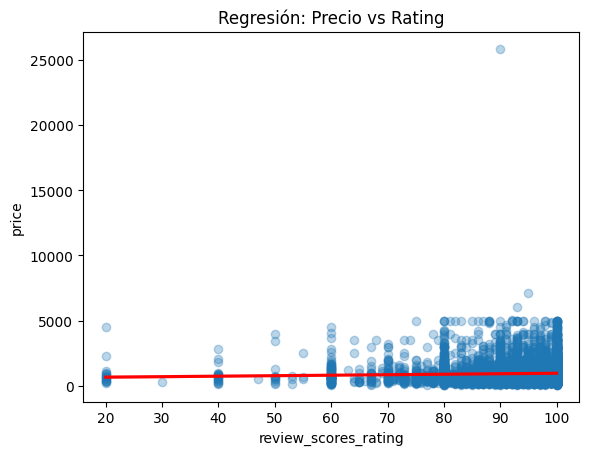

,price,review_scores_rating
price,1.000000,0.041133
review_scores_rating,0.041133,1.000000


In [34]:
sns.regplot(data=df, x='review_scores_rating', y='price', scatter_kws={'alpha':0.3}, line_kws={'color':'red'})

plt.title('Regresión: Precio vs Rating')
plt.show()

df[['price', 'review_scores_rating']].corr()

<Axes: >

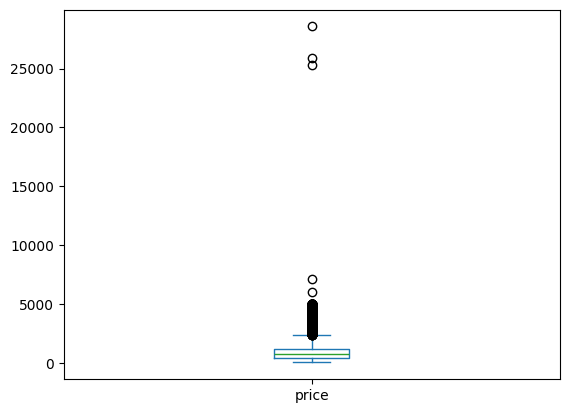

In [35]:
df['price'].plot.box()

In [36]:
df.groupby('city')[['price', 'review_scores_rating']].corr()

price  review_scores_rating
city                                                          
Barcelona price                 1.000000             -0.040943
          review_scores_rating -0.040943              1.000000
Girona    price                 1.000000              0.108110
          review_scores_rating  0.108110              1.000000
Madrid    price                 1.000000              0.033612
          review_scores_rating  0.033612              1.000000
Malaga    price                 1.000000              0.104378
          review_scores_rating  0.104378              1.000000
Mallorca  price                 1.000000              0.079720
          review_scores_rating  0.079720              1.000000
Menorca   price                 1.000000              0.094278
          review_scores_rating  0.094278              1.000000
Sevilla   price                 1.000000              0.011600
          review_scores_rating  0.011600              1.000000
Valencia  price                 1.000000              0.049133
          review_scores_rating  0.049133              1.000000

In [49]:
df['price'].max()

np.float64(28571.0)

Hay que analizar también la variable calidad_precio

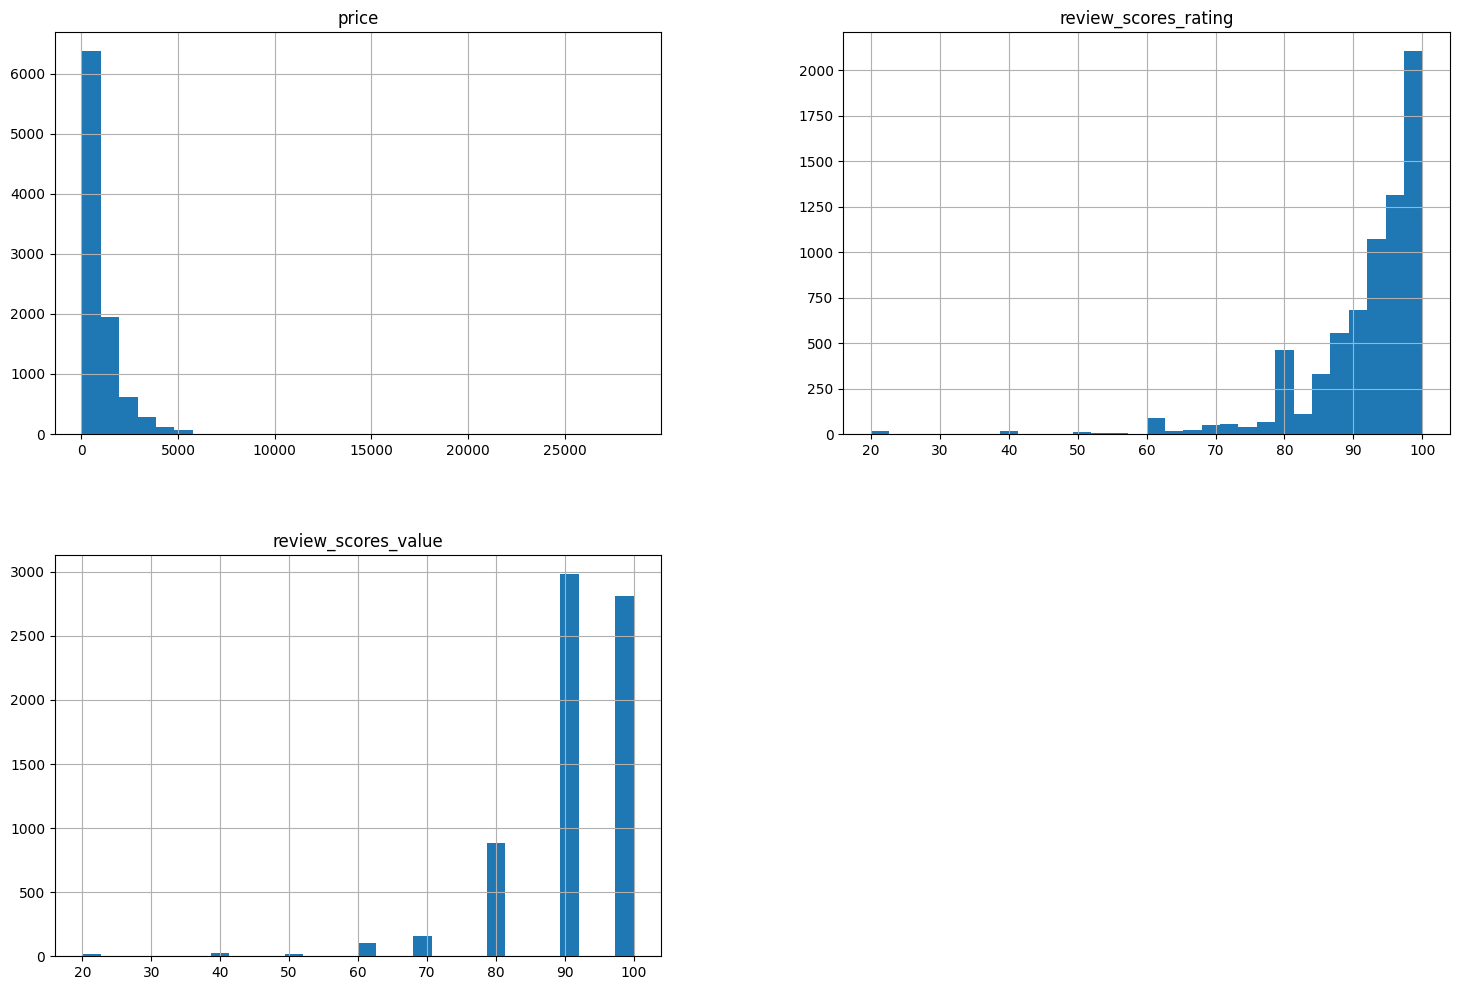

In [37]:
df[['price', 'review_scores_rating', 'review_scores_value']].hist(bins=30, figsize=(18, 12))
plt.show()

In [38]:
# Resumen de Precio medio y satisfacción media por ciudad 

summary = df.groupby('city').agg(
    precio_medio=('price', 'mean'),
    satisfaccion_media=('review_scores_rating', 'mean'),
    correlacion=('price', lambda x: x.corr(df.loc[x.index, 'review_scores_rating']))
).round(2)

print(summary)

           precio_medio  satisfaccion_media  correlacion
city                                                    
Barcelona        830.63               90.70        -0.04
Girona          1203.74               90.93         0.11
Madrid           792.82               92.63         0.03
Malaga           745.15               92.20         0.10
Mallorca        1655.68               92.99         0.08
Menorca         1651.16               93.36         0.09
Sevilla          944.73               93.54         0.01
Valencia         658.97               92.21         0.05


In [39]:
correlation = df['price'].corr(df['review_scores_rating'])
print(f"Correlación general: {correlation:.4f}")

Correlación general: 0.0411


In [40]:
corr_by_city = df.groupby('city')[['price', 'review_scores_rating']].corr().unstack()['price']['review_scores_rating']
print(corr_by_city)

city
Barcelona   -0.040943
Girona       0.108110
Madrid       0.033612
Malaga       0.104378
Mallorca     0.079720
Menorca      0.094278
Sevilla      0.011600
Valencia     0.049133
Name: review_scores_rating, dtype: float64


- Los valores van de -1 a +1:

- +1 → a más precio, más satisfacción (nos encontramos con relación perfecta positiva)
- -1 → a más precio, menos satisfacción (nos encontramos con relación perfecta positiva)
- 0 → sin relación


- Ciudad.         Valor
- Barcelona: 0.04 Ligerísima tendencia negativa (casi nula)
- Girona:    0.11 La correlación más alta, pero sigue siendo muy débil
- Madrid:    0.03 Prácticamente sin relación
- Málaga:    0.10 Débil positiva
- Mallorca:  0.08 Débil positiva
- Menorca:   0.09 Débil positiva
- Sevilla:   0.01 Sin relación
- Valencia:  0.05 Casi sin relación

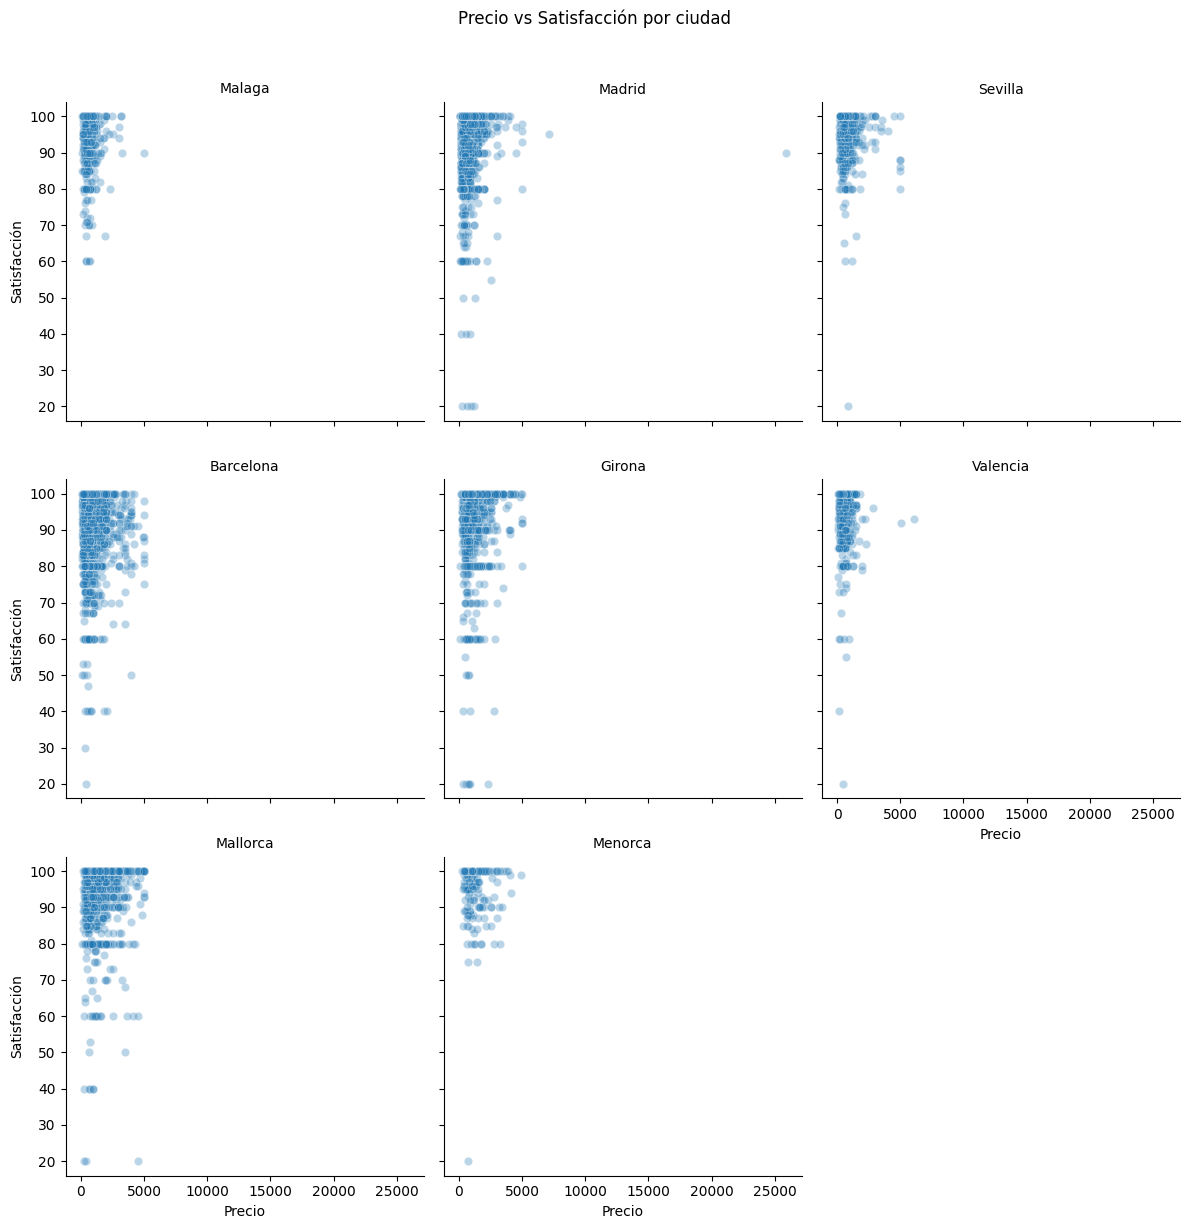

In [41]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.FacetGrid(df, col='city', col_wrap=3, height=4)
g.map_dataframe(sns.scatterplot, x='price', y='review_scores_rating', alpha=0.3)
g.set_axis_labels("Precio", "Satisfacción")
g.set_titles("{col_name}")
plt.suptitle("Precio vs Satisfacción por ciudad", y=1.02)
plt.tight_layout()
plt.show()

** La pregunta  "¿cómo afecta el precio a la satisfacción?", convierte al precio en la variable independiente (X) y a la satisfacción en la dependiente (Y). 
- El ojo humano lee el gráfico como "a medida que X aumenta, ¿qué pasa con Y?"
- Si lo invertimos, el gráfico sugeriría "¿cómo afecta la satisfacción al precio?", que es una causalidad menos natural en este contexto.

In [42]:
score_cols = ['review_scores_accuracy', 'review_scores_cleanliness', 
              'review_scores_checkin', 'review_scores_communication',
              'review_scores_location', 'review_scores_value']

df[score_cols + ['price']].corr()['price'].round(2)

review_scores_accuracy        -0.01
review_scores_cleanliness      0.04
review_scores_checkin         -0.02
review_scores_communication   -0.00
review_scores_location         0.00
review_scores_value           -0.03
price                          1.00
Name: price, dtype: float64

In [43]:
df.groupby('room_type').apply(lambda x: x['price'].corr(x['review_scores_rating']))

/var/folders/5y/8m8svsnn57327yxs9qz4m9gc0000gn/T/ipykernel_51455/2757139164.py:1: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('room_type').apply(lambda x: x['price'].corr(x['review_scores_rating']))


room_type
Entire home/apt    0.060799
Hotel room         0.238005
Private room      -0.043478
Shared room       -0.186053
dtype: float64

In [44]:
df['room_type'].value_counts()

room_type
Entire home/apt    6676
Private room       2821
Hotel room           81
Shared room          72
Name: count, dtype: int64

- Los alojamientos más caros tienden a recibir ligeramente menos reviews.


- Los alojamientos caros se reservan menos frecuentemente, generando menos reviews
O simplemente que el precio no atrae más reservas

- Sin embargo con -0.13 sigue siendo una relación muy débil, no concluyente.

In [45]:
df['price'].corr(df['number_of_reviews']).round(2)

np.float64(-0.13)

In [46]:
# General
correlation_spearman = df['price'].corr(df['review_scores_rating'], method='spearman')
print(f"Correlación Spearman: {correlation_spearman:.4f}")

# Por ciudad
corr_by_city_spearman = df.groupby('city')[['price', 'review_scores_rating']].corr(method='spearman').unstack()['price']['review_scores_rating']
print(corr_by_city_spearman)

# Por room_type
df.groupby('room_type').apply(lambda x: x['price'].corr(x['review_scores_rating'], method='spearman'))

Correlación Spearman: 0.0889
city
Barcelona   -0.051117
Girona       0.172790
Madrid       0.071404
Malaga       0.161937
Mallorca     0.195304
Menorca      0.084560
Sevilla      0.080597
Valencia     0.089619
Name: review_scores_rating, dtype: float64


/var/folders/5y/8m8svsnn57327yxs9qz4m9gc0000gn/T/ipykernel_51455/3776365391.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df.groupby('room_type').apply(lambda x: x['price'].corr(x['review_scores_rating'], method='spearman'))


room_type
Entire home/apt    0.133236
Hotel room         0.228727
Private room       0.059282
Shared room       -0.305444
dtype: float64

- Comparativa rápida:
- --------------Pearson ----Spearman--------------
- General -----   -0.04 -----  0.09
- Barcelona ---   -0.04  ----- -0.05
- Girona  -----    0.11  ----  0.17
- Mallorca ----    0.08  -----  0.20
- Málaga. ------   0.10.  ----- 0.16

In [ ]:
df.sort_values(by='price', ascending=False).head(3) #Los 3 outliers

,apartment_id,name,description,host_id,neighbourhood_name,neighbourhood_district,room_type,accommodates,bathrooms,bedrooms,beds,amenities_list,price,minimum_nights,maximum_nights,has_availability,availability_30,availability_60,availability_90,availability_365,number_of_reviews,first_review_date,last_review_date,review_scores_rating,review_scores_accuracy,review_scores_cleanliness,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,is_instant_bookable,reviews_per_month,country,city,insert_date,price_missing,reviews 80+
9192,41372147,"VILLA VERD, nice villa in the country.","Villa Verd is a beautiful country house, finis...",313785862,Alc�dia,(sin contestar),Entire home/apt,6,2.0,3.0,5.0,"Iron, TV, Kitchen, Hair dryer, Free street par...",28571.0,1,1125,True,30,60,63,194,0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,spain,Mallorca,2020-08-28,False,NaN
8658,37153661,Unique Luxury Apartment 6People Pool & Facilities,250 square meters - Exclusive luxury apartment...,42407188,Mirasierra,Fuencarral - El Pardo,Entire home/apt,6,5.0,5.0,5.0,"Iron, Coffee maker, Fire extinguisher, Wifi, T...",25857.0,3,1125,True,18,47,77,279,3,2019-08-05,2019-12-14,90.0,100.0,100.0,100.0,100.0,100.0,90.0,False,22.0,spain,Madrid,2020-09-13,False,True
9302,42188834,Roman Room by Hotel Mam�,<b>The space</b><br />Looks like a small cinem...,333351874,Palma de Mallorca,(sin contestar),Private room,2,1.0,1.0,1.0,"Hair dryer, Shampoo, Air conditioning, Bathtub...",25286.0,1,1125,True,0,0,0,267,0,NaT,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,True,NaN,spain,Mallorca,2020-08-28,False,NaN


In [55]:
# Calcular los cortes en percentiles 33 y 66
q33 = df['price'].quantile(0.33)
q66 = df['price'].quantile(0.66)

print(f"Corte económico/medio: {q33:.2f}")
print(f"Corte medio/premium: {q66:.2f}")

# Crear la segmentación
df['price_segment'] = pd.cut(df['price'], 
                              bins=[-float('inf'), q33, q66, float('inf')],
                              labels=['Económico', 'Medio', 'Premium'])

df['price_segment'].value_counts()

Corte económico/medio: 550.00
Corte medio/premium: 1000.00


price_segment
Económico    3279
Medio        3077
Premium      3053
Name: count, dtype: int64

- **Económico:** hasta 550€
- **Medio:** 550€ - 1.000€
- **Premium:** más de 1.000€

In [57]:
#Satisfacción por segmento

df.groupby('price_segment')['review_scores_rating'].mean().round(2)

/var/folders/5y/8m8svsnn57327yxs9qz4m9gc0000gn/T/ipykernel_51455/3564600711.py:3: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('price_segment')['review_scores_rating'].mean().round(2)


price_segment
Económico    91.43
Medio        91.69
Premium      92.68
Name: review_scores_rating, dtype: float64